# Pruebas STAR

## Código base

In [1]:
source("utils.r")
source("preparar_dataframes.r")
library(tsDyn)

[1] "Se creó df_trimestral_crudo"
[1] "Se creó df_Arg"
[1] "Se creó df_ERPT_Arg1"
[1] "Se creó df_ERPT_Arg"


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 



## Experimentos

In [2]:
df_ERPT_Arg

,año,trimestre,ipc,E,Ebc,pbird,impp_usa,Psoja_USA,Pmaíz_USA,Ptrigo_USA,TOTfmi
,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,1950,2ºTr,0.0710476068,0.000000e+00,0.000000e+00,-0.016444578,NA,0.209470249,0.123481057,0.058301271,NA
3,1950,3ºTr,0.0485426448,1.822569e-01,1.822569e-01,0.037674929,NA,-0.048727588,0.087011377,-0.046365921,NA
4,1950,4ºTr,0.0686389229,2.596392e-01,2.596392e-01,-0.012975314,NA,-0.045706880,-0.030554668,-0.006802747,NA
5,1951,1ºTr,0.0228032118,1.405321e-03,1.405321e-03,0.027127918,NA,0.222317901,0.123336402,0.091268514,NA
6,1951,2ºTr,0.1578569708,4.855918e-03,4.855918e-03,0.012084985,NA,0.016384856,0.029108084,-0.014117882,NA
7,1951,3ºTr,0.1057701537,6.299697e-03,6.299697e-03,-0.006213927,NA,-0.123214880,0.010193768,-0.025601398,NA
8,1951,4ºTr,0.0767790005,1.347034e-02,1.347034e-02,-0.004386448,NA,0.007326040,0.000000000,0.053640618,NA
9,1952,1ºTr,0.1087066196,-1.618821e-02,-1.618821e-02,0.002419679,NA,0.012092046,0.010090903,0.010695289,NA
10,1952,2ºTr,0.0994670088,-1.171674e-02,-1.171674e-02,-0.032405660,NA,0.022579688,0.025769513,-0.032435276,NA


# Librerías

In [3]:
library(tsDyn)
library(vars)
library(dplyr)
library(ggplot2)


Loading required package: MASS



Loading required package: strucchange

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Loading required package: urca

Loading required package: lmtest


Attaching package: ‘dplyr’


The following object is masked from ‘package:MASS’:

    select


The following object is masked from ‘package:gridExtra’:

    combine


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




# Configuración general

In [4]:
############################################################
# CONFIGURACIÓN 5 lags (según Selected Orders de VAR)
############################################################

lag_var        <- 5        # número de rezagos
use_scaled_ipc <- FALSE    # NO CAMBIAR. TRUE = usar ipc estandarizada
use_maíz_endog <- TRUE     # FALSE = tratar maíz como exógena (por ahora solo quita del sistema)

nboot_test     <- 200
trim_value     <- 0.15
nthresh_value  <- 1        # 1 → dos regímenes
thDelay_value  <- 1
include_type   <- "const"


# Preparar dataset

In [5]:
############################################################
# 1. Preparar variables
############################################################

df <- df_ERPT_Arg

# Variable de transición
ipc_trans <- df$ipc
if(use_scaled_ipc){
  ipc_trans <- scale(ipc_trans)
}

# Endógenas
if(use_maíz_endog){
  Y <- cbind(df$Pmaíz_USA, df$E, df$ipc, df$pbird)
  colnames(Y) <- c("Pmaíz_USA","E","ipc","pbird")
} else {
  Y <- cbind(df$E, df$ipc, df$pbird)
  colnames(Y) <- c("E","ipc","pbird")
}


# Test de linealidad (TVAR.LRtest) 
Esto devuelve: estadístico LR; p-value bootstrap; valores críticos. Si p-value < 0.05 hay evidencia de no linealidad. 

In [6]:
############################################################
# 2. Test de linealidad
############################################################

test_lin <- TVAR.LRtest(
  data   = Y,
  lag    = lag_var,
  series = "ipc",
  thDelay= thDelay_value,
  thVar  = ipc_trans,
  trim   = trim_value,
  nboot  = nboot_test,
  test   = "1vs",
  model  = "TAR"
)

print(test_lin)

Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”


Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning message in FUN(newX[, i], ...):
“Tolerance reached, ndp possibly underestimated.”
Warning me

Test of linear VAR against TVAR(1) and TVAR(2)

LR test:
          1vs2     1vs3
Test  368.0118 533.1793
P-Val   0.0000   0.0000


# Estimación TVAR

In [8]:
############################################################
# 3. Estimar TVAR
############################################################

tvar_model <- TVAR(
  data     = Y,
  lag      = lag_var,
  include  = include_type,
  model    = "TAR",
  nthresh  = nthresh_value,
  thDelay  = thDelay_value,
  mTh      = if (use_maíz_endog) 3 else 2,
  trim     = trim_value,
  trace    = TRUE
)

summary(tvar_model)


Best unique threshold 0.2405847 


Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minlength = abbr.colnames):
“abbreviate used with non-ASCII chars”
Warning message in abbreviate(dimnames(ans)[[2L]], minle

Model TVAR with  1  thresholds

Full sample size: 295 	End sample size: 290
Number of variables: 4 	Number of estimated parameters: 168 + 1
AIC -6094.805 	BIC -5474.595 	 SSR 9.897256 

[[1]]
                   Intercept        Pmaíz_USA -1      E -1             
Equation Pmaíz_USA 0.0009(0.0103)   0.2676(0.0676)*** -0.0292(0.0644)  
Equation E         0.0133(0.0172)   -0.1196(0.1125)   0.4865(0.1073)***
Equation ipc       0.0018(0.0078)   0.0172(0.0512)    0.1486(0.0488)** 
Equation pbird     0.0092(0.0029)** -0.0091(0.0190)   -0.0143(0.0181)  
                   ipc -1            pbird -1         Pmaíz_USA -2      
Equation Pmaíz_USA 0.4276(0.1838)*   0.5474(0.2416)*  -0.2343(0.0700)***
Equation E         0.0406(0.3061)    -0.7284(0.4023). 0.2132(0.1166).   
Equation ipc       0.6502(0.1393)*** 0.0316(0.1831)   0.0024(0.0531)    
Equation pbird     -0.0628(0.0518)   0.0867(0.0681)   0.0397(0.0197)*   
                   E -2             ipc -2           pbird -2        
Equation Pmaí

In [9]:
table(regime(tvar_model))


  1   2 
245  45 

# GRÁFICOS

## Configuración global: usando tvar_model
1. ERPT por régimen (IRF del TVAR)
2. ERPT rolling en el tiempo
3. Horizonte 4 y 8 trimestres

In [11]:
data_model <- df_ERPT_Arg[, c("Pmaíz_USA","E","ipc","pbird")]
data_model <- na.omit(data_model)

lag_var   <- lag_var
nthresh   <- nthresh_value
trim_val  <- trim_value
nboot_irf <- nboot_test

shock_var <- "E"
resp_var  <- "ipc"

h_short <- 4
h_long  <- 8


In [12]:
# Renombro test de linearidad para que coincida con el resto del codigo
lr_test <- test_lin


## IRF por regimen ABSOLUTAS

In [13]:
irf_r1 <- vars::irf(
  tvar_model,
  impulse = shock_var,
  response = resp_var,
  regime = "L",
  n.ahead = h_long,
  boot = TRUE,
  runs = nboot_irf,
  ci = 0.68,
  cumulative = FALSE,
  ortho = FALSE
)

In [14]:
irf_r2 <- vars::irf(tvar_model, impulse=shock_var, response=resp_var,
              regime="H", n.ahead=h_long, boot=TRUE, runs=nboot_irf,
              ci = 0.68, cumulative = FALSE, ortho = FALSE)

## ERPT por régimen

In [15]:
get_erpt <- function(irf_obj, h){
  cumsum(irf_obj$irf$E[,"ipc"])[h+1]
}

erpt_reg <- data.frame(
  regime = c("Baja","Alta"),
  ERPT_4 = c(get_erpt(irf_r1,4),
             get_erpt(irf_r2,4)),
  ERPT_8 = c(get_erpt(irf_r1,8),
             get_erpt(irf_r2,8))
)

print(erpt_reg)


  regime   ERPT_4   ERPT_8
1   Baja 0.492770 1.092066
2   Alta 1.182787 1.449802


## Gráfico IRF ABSOLUTAS

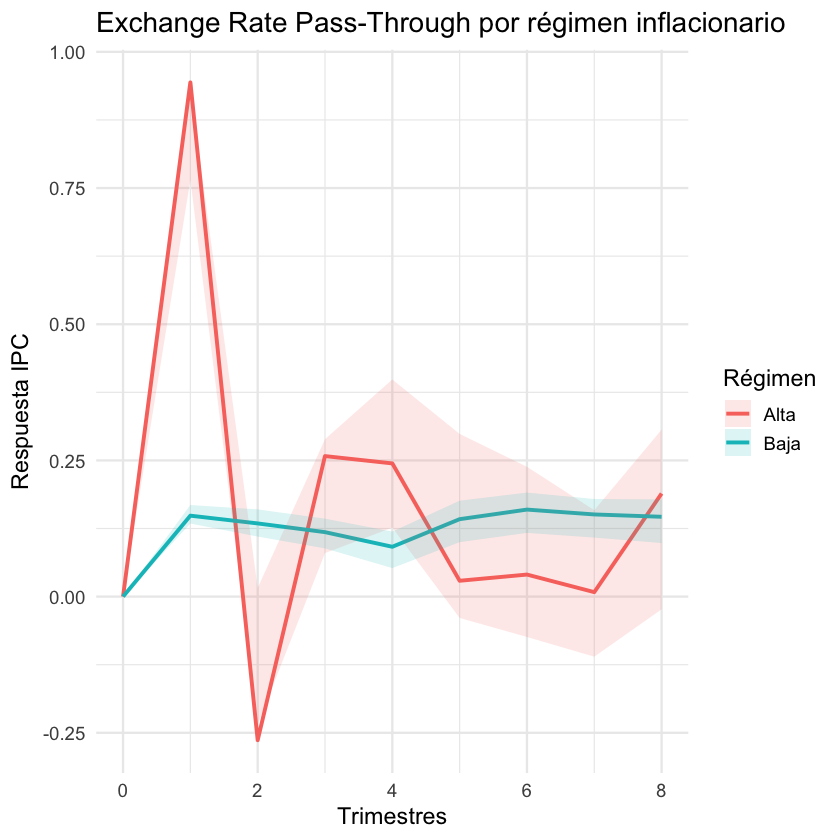

In [17]:
extract_irf <- function(irf_obj, shock, response){

  irf_mat <- irf_obj$irf[[shock]]
  lo_mat  <- irf_obj$Lower[[shock]]
  hi_mat  <- irf_obj$Upper[[shock]]

  data.frame(
    h   = 0:(nrow(irf_mat)-1),
    irf = irf_mat[, response],
    lo  = lo_mat[, response],
    hi  = hi_mat[, response]
  )
}

df1 <- extract_irf(irf_r1, shock = shock_var, response = resp_var); df1$reg="Baja"
df2 <- extract_irf(irf_r2, shock = shock_var, response = resp_var); df2$reg="Alta"

df_all <- rbind(df1,df2)

ggplot(df_all, aes(h, irf, color=reg, fill=reg))+
  geom_line(linewidth=1.1)+
  geom_ribbon(aes(ymin=lo, ymax=hi), alpha=.15, color=NA)+
  theme_minimal(base_size = 14)+
  labs(title="Exchange Rate Pass-Through por régimen inflacionario",
       y="Respuesta IPC",
       x="Trimestres",
       color="Régimen",
       fill="Régimen")


In [18]:
df_all


h,irf,lo,hi,reg
<int>,<dbl>,<dbl>,<dbl>,<chr>
0,0.00000000,0.00000000,0.00000000,Baja
1,0.14858711,0.13412079,0.16817268,Baja
2,0.13434914,0.11021890,0.16011177,Baja
3,0.11834534,0.08848138,0.14314410,Baja
4,0.09148836,0.05234865,0.11938071,Baja
5,0.14215062,0.09991241,0.17614532,Baja
6,0.15975411,0.11695203,0.19100323,Baja
7,0.15083693,0.10828888,0.17918811,Baja
8,0.14655398,0.09831556,0.17850715,Baja


In [19]:
irf_r1$ortho


[1] FALSE

## IRF por régimen ACUMULADAS

Acumulo manualmente las IRF absolutas (el paquete tsDyn no tiene IRF acumuladas)

In [20]:
extract_irf_cum <- function(irf_obj, shock, resp){

  # respuesta puntual
  irf_mat <- irf_obj$irf[[shock]][, resp]
  lo_mat  <- irf_obj$Lower[[shock]][, resp]
  hi_mat  <- irf_obj$Upper[[shock]][, resp]

  data.frame(
    h  = 0:(length(irf_mat)-1),
    irf = cumsum(irf_mat),
    lo  = cumsum(lo_mat),
    hi  = cumsum(hi_mat)
  )
}


In [21]:
df1 <- extract_irf_cum(irf_r1, shock_var, resp_var); df1$reg="Baja"
df2 <- extract_irf_cum(irf_r2, shock_var, resp_var); df2$reg="Alta"

df_all <- rbind(df1, df2)


In [22]:
df_all

h,irf,lo,hi,reg
<int>,<dbl>,<dbl>,<dbl>,<chr>
0,0.0000000,0.0000000,0.0000000,Baja
1,0.1485871,0.1341208,0.1681727,Baja
2,0.2829362,0.2443397,0.3282844,Baja
3,0.4012816,0.3328211,0.4714285,Baja
4,0.4927700,0.3851697,0.5908093,Baja
5,0.6349206,0.4850821,0.7669546,Baja
6,0.7946747,0.6020342,0.9579578,Baja
7,0.9455116,0.7103230,1.1371459,Baja
8,1.0920656,0.8086386,1.3156531,Baja


## Gráficos IRF ACUMULADAS

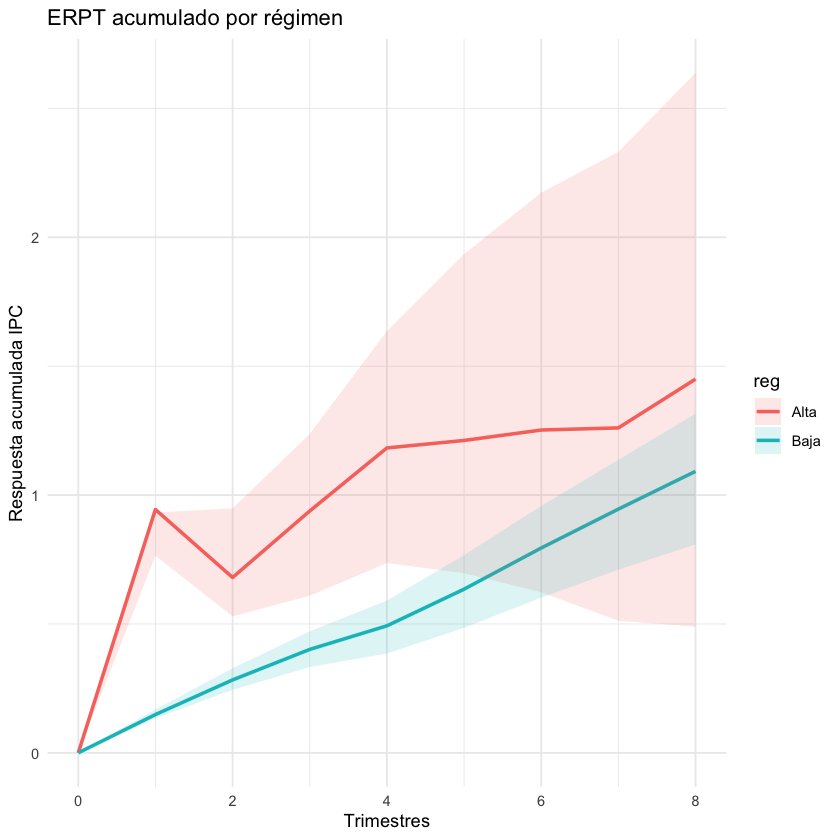

In [23]:
library(ggplot2)

ggplot(df_all, aes(h, irf, color=reg))+
  geom_line(linewidth=1)+
  geom_ribbon(aes(ymin=lo, ymax=hi, fill=reg),
              alpha=.15, color=NA)+
  theme_minimal()+
  labs(title="ERPT acumulado por régimen",
       y="Respuesta acumulada IPC",
       x="Trimestres")
